In [2]:
def getCrossigns(n, u_sign=1, l_sign=1):
    upper, lower, sign = [], [], []
    for k in range(n):
        u, l, m = 12*k, 12*k+2, 12*k+4
        upper += [u_sign*(u+1), -u_sign*(u+2)] + [-(m+1), -(m+2), (m+5), (m+6)] + [u_sign*(u+2), -u_sign*(u+1)]
        lower += [-l_sign*(l+1), l_sign*(l+2)] + [(m+4), (m+2), -(m+5), -(m+7)] + [-l_sign*(l+2), l_sign*(l+1)]
    for k in range(n-1, -1, -1):
        m = 12*k+4
        upper += [(m+8), (m+7), -(m+4), -(m+3)]
        lower += [-(m+8), -(m+6), (m+1), (m+3)]
    sign = [[u_sign]*2 + [l_sign]*2 + [1, -1, -1, 1, -1, 1, 1, -1]]*n
    sign = [item for gadget in sign for item in gadget]
    return [[upper, lower], sign]

In [3]:
def changeCrossing(link, crossings):
    pd_code = [x for x in link.pd_code()]
    for i in crossings:
        sign = link.orientation()[i]
        a,b,c,d=pd_code[i]
        if sign < 0:
            pd_code[i] = [b,c,d,a]
        else:
            pd_code[i] = [d,a,b,c]
    return Link(pd_code)
    

In [116]:
crossings = getCrossigns(1, u_sign=-1, l_sign=-1)
print(*crossings[0], crossings[1], sep='\n')
print(len(crossings[0][0]), len(crossings[0][1]), len(crossings[1]))

[-1, 2, -5, -6, 9, 10, -2, 1, 12, 11, -8, -7]
[3, -4, 8, 6, -9, -11, 4, -3, -12, -10, 5, 7]
[-1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1, -1]
12 12 12


In [12]:
crossings = getCrossigns(2, u_sign=-1, l_sign=-1)
L = Link(crossings)
L.plot()
L.jones_polynomial()

-t^(9/2) + 4*t^(7/2) - 7*t^(5/2) + 3*t^(3/2) + 10*sqrt(t) - 29/sqrt(t) + 45/t^(3/2) - 54/t^(5/2) + 46/t^(7/2) - 29/t^(9/2) + 4/t^(11/2) + 25/t^(13/2) - 43/t^(15/2) + 48/t^(17/2) - 41/t^(19/2) + 26/t^(21/2) - 13/t^(23/2) + 5/t^(25/2) - 1/t^(27/2)

In [175]:
crossings = getCrossigns(2, u_sign=-1, l_sign=-1)
L = Link(crossings)
L.plot()
C = len(L.orientation())
witness=[]
for i in range(C):
    print(f'{i/C*100}%')
    for j in range(i+1, C):
        L1 = changeCrossing(L, [i,j])
        s = L1.signature()
        if s == 0:
            # print((i,j,k))
            witness+=[(i,j)]
print(witness)

0.0%
4.166666666666666%
8.333333333333332%
12.5%
16.666666666666664%
20.833333333333336%
25.0%
29.166666666666668%
33.33333333333333%
37.5%
41.66666666666667%
45.83333333333333%
50.0%
54.166666666666664%
58.333333333333336%
62.5%
66.66666666666666%
70.83333333333334%
75.0%
79.16666666666666%
83.33333333333334%
87.5%
91.66666666666666%
95.83333333333334%
[]


1 5 2 4


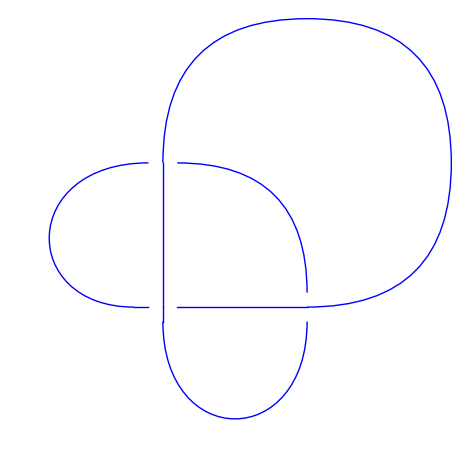

In [83]:
T = Knot([[1, 5, 2, 4], [3, 1, 4, 6], [5, 3, 6, 2]])
T1 = changeCrossing(T, 1)
T1.plot()

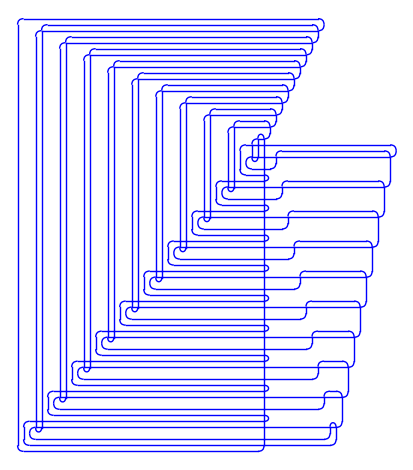

In [7]:
crossings = getCrossigns(10, u_sign=-1, l_sign=-1)
L = Link(crossings)
L.plot()